<a href="https://colab.research.google.com/github/HelloPenguin1/Spinal_Metastasis_Classification_TCIA/blob/main/Model_Train_Baseline3D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy
import sklearn
import torch

print(numpy.__version__)
print(sklearn.__version__)
print(torch.__version__)

2.0.2
1.6.1
2.11.0+cu128


In [3]:
!pip install -q monai SimpleITK nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 20.5 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight

from monai.transforms import (
    Compose,
    RandFlip,
    RandRotate,
    RandZoom,
)

import SimpleITK as sitk
import nibabel as nib
from monai.data import set_track_meta

In [5]:
df = pd.read_csv('/content/labels.csv')

In [6]:
set_track_meta(False)

Loading Dataset Index

In [7]:
df.head()

,filename,label
0,10250_T2.npy,Mixed
1,10352_T11.npy,No Lesion
2,10352_T12.npy,No Lesion
3,10352_L1.npy,No Lesion
4,10352_L2.npy,No Lesion


Extracting Patient ID and Vertebrae Level from the filename

In [20]:
df['Patient_ID'] = df['filename'].apply(lambda x: x.split('_')[0])
df['Vertebra_Level'] = df['filename'].apply(lambda x: x.split('_')[1].replace('.npy', ''))

In [21]:
print("=== Dataset Summary for Research Paper ===")
print(f"Total Unique Patients: {df['Patient_ID'].nunique()}")
print(f"Total 3D Volumes Extracted: {len(df)}")
print(f"Average Volumes per Patient: {len(df) / df['Patient_ID'].nunique():.1f}")
print("\nExact Class Counts:")
print(df['label'].value_counts())
print("\nClass Percentages:")
print((df['label'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')

=== Dataset Summary for Research Paper ===
Total Unique Patients: 52
Total 3D Volumes Extracted: 289
Average Volumes per Patient: 5.6

Exact Class Counts:
label
No Lesion    116
Mixed         76
Blastic       55
Lytic         42
Name: count, dtype: int64

Class Percentages:
label
No Lesion    40.1%
Mixed        26.3%
Blastic      19.0%
Lytic        14.5%
Name: proportion, dtype: object


These patients were remvoed due to lack of segmentation mask

In [22]:
original_df = pd.read_csv('drive/MyDrive/TCIA_Data/vertebra_labels_claude.csv')
expected_patients = set(original_df['Case'].astype(str))
processed_patients = set(df['filename'].apply(lambda x: x.split('_')[0]))
missing_patients = expected_patients - processed_patients
print(f"Missing Patients: {missing_patients}")

Missing Patients: {'13653', '14826', '14797'}


## Data Visualization


In [ ]:
sns.set_theme(style="whitegrid")

/tmp/ipykernel_802/3315715234.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', order=['No Lesion', 'Lytic', 'Blastic', 'Mixed'], palette='mako')


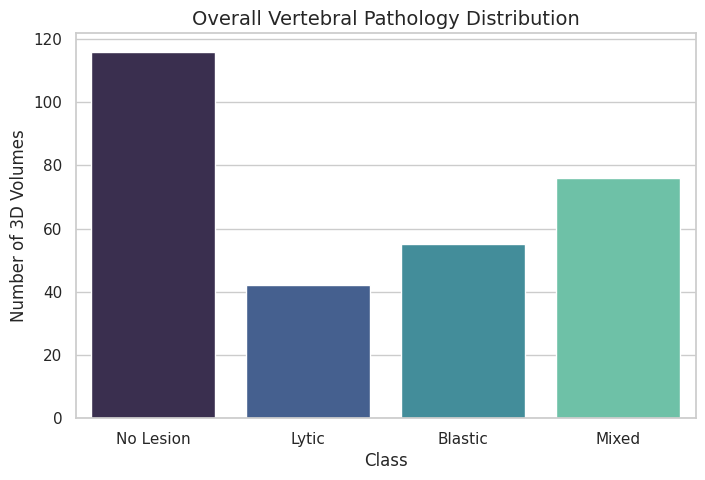

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', order=['No Lesion', 'Lytic', 'Blastic', 'Mixed'], palette='mako')
plt.title('Overall Vertebral Pathology Distribution', fontsize=14)
plt.ylabel('Number of 3D Volumes', fontsize=12)
plt.xlabel('Class', fontsize=12)
plt.show()

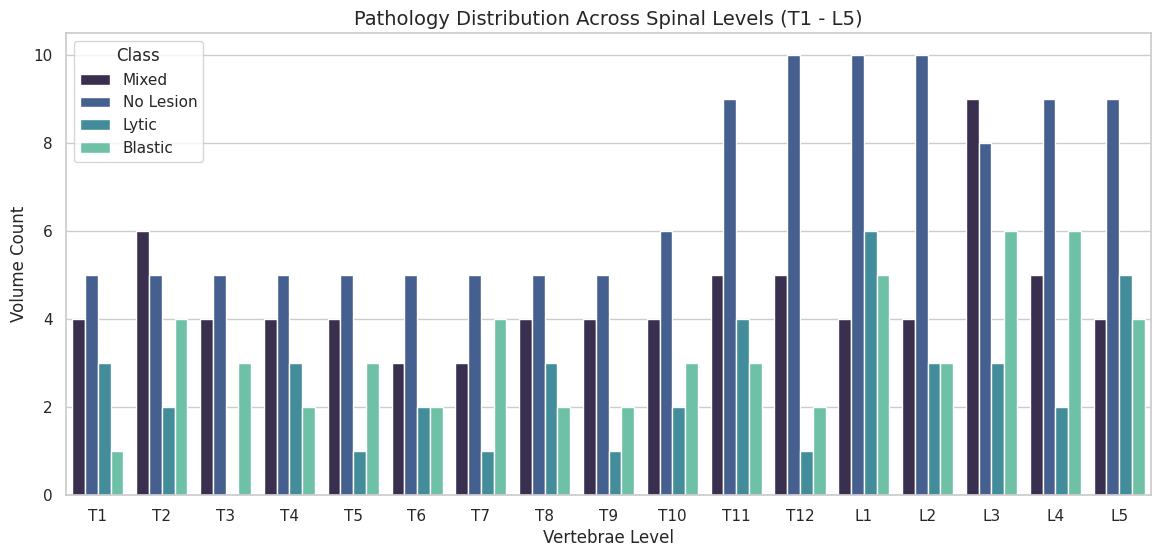

In [ ]:
vert_order = [f'T{i}' for i in range(1, 13)] + [f'L{i}' for i in range(1, 6)]

plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='Vertebra_Level', hue='label', order=vert_order, palette='mako')
plt.title('Pathology Distribution Across Spinal Levels (T1 - L5)', fontsize=14)
plt.xlabel('Vertebrae Level', fontsize=12)
plt.ylabel('Volume Count', fontsize=12)
plt.legend(title='Class')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
import os

Loading Data and Split By Patient

In [ ]:
df['label']

,label
0,Mixed
1,No Lesion
2,No Lesion
3,No Lesion
4,No Lesion
...,...
284,Lytic
285,Lytic
286,Lytic
287,Lytic


In [12]:
#Label Mapping
label_mapping = {'No Lesion': 0, 'Lytic': 1, 'Blastic': 2, 'Mixed': 3}
df['label_int'] = df['label'].map(label_mapping)

In [13]:
df['label_int']

,label_int
0,3
1,0
2,0
3,0
4,0
...,...
284,1
285,1
286,1
287,1


Stratified Split (80% Train, 20% Val) ensuring patient isolation



In [14]:
TENSOR_DIR = "drive/MyDrive/TCIA_Original/tensors"

In [ ]:
def parse_npy_file(filename, label):
    filepath = os.path.join(TENSOR_DIR, filename.decode('utf-8'))
    tensor = np.load(filepath).astype(np.float32)
    return np.expand_dims(tensor, axis=-1), label

def tf_load_wrapper(filename, label):
    tensor, label = tf.numpy_function(func=parse_npy_file, inp=[filename, label], Tout=[tf.float32, tf.int32])
    tensor.set_shape((64, 64, 64, 1))
    label.set_shape(())
    return tensor, label

def create_dataset(dataframe, batch_size=8, is_training=False):
    ds = tf.data.Dataset.from_tensor_slices((dataframe['filename'].values, dataframe['label_int'].values))
    if is_training: ds = ds.shuffle(buffer_size=len(dataframe))
    ds = ds.map(tf_load_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

3D CNN

In [ ]:
import numpy as np

### 3D CNN V1 - Test

In [28]:
def build_3d_cnn(input_shape=(64, 64, 64, 1), num_classes=4):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv3D(32, kernel_size=3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling3D(pool_size=2)(x)
    x = layers.Conv3D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling3D(pool_size=2)(x)
    x = layers.Conv3D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling3D(pool_size=2)(x)
    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
K_FOLDS = 5
sgkf = StratifiedGroupKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

fold_metrics = [] #for storing results

print(f"Starting {K_FOLDS}-Fold Cross Validation...")

# split() takes: (X, y, groups)
for fold, (train_idx, val_idx) in enumerate(sgkf.split(df, df['label_int'], df['Patient_ID'])):
    print(f"               FOLD {fold + 1}")
    print(f"{'='*40}")

    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]

    print(f"Training on {train_df['Patient_ID'].nunique()} patients ({len(train_df)} volumes)")
    print(f"Testing on {val_df['Patient_ID'].nunique()} patients ({len(val_df)} volumes)")

    # casting label to int32
    train_df['label_int'] = train_df['label_int'].astype(np.int32)
    val_df['label_int'] = val_df['label_int'].astype(np.int32)

    # 1. Compute dynamic weights for this fold train set
    weights = compute_class_weight('balanced', classes=np.unique(train_df['label_int']), y=train_df['label_int'])
    class_weights_dict = {i: weight for i, weight in enumerate(weights)}

    # 2. Build TF Datasets
    train_ds = create_dataset(train_df, batch_size=8, is_training=True)
    val_ds = create_dataset(val_df, batch_size=8, is_training=False)

    # 3. Build a new model and prevent weight leaks
    tf.keras.backend.clear_session()
    model = build_3d_cnn()

    # 4. Model train with few initial epochs for testing
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        class_weight=class_weights_dict,
        verbose=1
    )

    # 5. final validation accuracy
    final_val_acc = history.history['val_accuracy'][-1]
    fold_metrics.append(final_val_acc)
    print(f"Fold {fold + 1} Final Validation Accuracy: {final_val_acc:.4f}")

Starting 5-Fold Cross Validation...
               FOLD 1
Training on 39 patients (243 volumes)
Testing on 13 patients (46 volumes)


/tmp/ipykernel_802/1746631277.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['label_int'] = train_df['label_int'].astype(np.int32)
/tmp/ipykernel_802/1746631277.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df['label_int'] = val_df['label_int'].astype(np.int32)


Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.2428 - loss: 1.9533 - val_accuracy: 0.1304 - val_loss: 1.4092
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.4033 - loss: 1.4388 - val_accuracy: 0.3913 - val_loss: 1.3769
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.4280 - loss: 1.3320 - val_accuracy: 0.5217 - val_loss: 1.2962
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.4527 - loss: 1.2776 - val_accuracy: 0.5217 - val_loss: 1.2169
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.4691 - loss: 1.2765 - val_accuracy: 0.5217 - val_loss: 1.1801
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.4733 - loss: 1.2138 - val_accuracy: 0.5217 - val_loss: 1.1799
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.4321 - loss: 1.2621 - val_accuracy: 0.5217 - val_loss: 1.1841
Epoch 8/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.4938 - loss: 1.1371 - val_accuracy: 0.5217 - v

/tmp/ipykernel_802/1746631277.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['label_int'] = train_df['label_int'].astype(np.int32)
/tmp/ipykernel_802/1746631277.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df['label_int'] = val_df['label_int'].astype(np.int32)


Epoch 1/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 330ms/step - accuracy: 0.2709 - loss: 1.8104 - val_accuracy: 0.2209 - val_loss: 1.4094
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.3744 - loss: 1.5062 - val_accuracy: 0.1279 - val_loss: 1.4425
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.3990 - loss: 1.3783 - val_accuracy: 0.3256 - val_loss: 1.4694
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.3498 - loss: 1.4450 - val_accuracy: 0.3140 - val_loss: 1.5000
Epoch 5/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.3498 - loss: 1.4442 - val_accuracy: 0.3140 - val_loss: 1.5450
Epoch 6/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.4384 - loss: 1.3168 - val_accuracy: 0.3140 - val_loss: 1.5540
Epoch 7/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.3645 - loss: 1.3460 - val_accuracy: 0.3140 - val_loss: 1.5338
Epoch 8/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.3941 - loss: 1.2734 - val_accuracy: 0

...

Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 376ms/step - accuracy: 0.2857 - loss: 1.7694 - val_accuracy: 0.0682 - val_loss: 1.4677
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.3918 - loss: 1.4393 - val_accuracy: 0.0682 - val_loss: 1.5506
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.4122 - loss: 1.3982 - val_accuracy: 0.0682 - val_loss: 1.7028
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.4571 - loss: 1.2717 - val_accuracy: 0.0682 - val_loss: 1.8573
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.4245 - loss: 1.2987 - val_accuracy: 0.0682 - val_loss: 2.0565
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.5306 - loss: 1.1117 - val_accuracy: 0.0682 - val_loss: 2.1747
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.5306 - loss: 1.1595 - val_accuracy: 0.0682 - val_loss: 2.2114
Epoch 8/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.5469 - loss: 1.1599 - val_accuracy: 0.068

/tmp/ipykernel_802/1746631277.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['label_int'] = train_df['label_int'].astype(np.int32)
/tmp/ipykernel_802/1746631277.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df['label_int'] = val_df['label_int'].astype(np.int32)


Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 399ms/step - accuracy: 0.3451 - loss: 1.9476 - val_accuracy: 0.3016 - val_loss: 1.3764
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.3097 - loss: 1.5742 - val_accuracy: 0.3016 - val_loss: 1.3870
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.3673 - loss: 1.4294 - val_accuracy: 0.3016 - val_loss: 1.3890
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.4513 - loss: 1.2570 - val_accuracy: 0.3016 - val_loss: 1.3828
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.4469 - loss: 1.2641 - val_accuracy: 0.3810 - val_loss: 1.3950
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.4425 - loss: 1.3133 - val_accuracy: 0.3016 - val_loss: 1.4120
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.4646 - loss: 1.2151 - val_accuracy: 0.3016 - val_loss: 1.3935
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.4867 - loss: 1.1668 - val_accuracy: 0

/tmp/ipykernel_802/1746631277.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['label_int'] = train_df['label_int'].astype(np.int32)
/tmp/ipykernel_802/1746631277.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df['label_int'] = val_df['label_int'].astype(np.int32)


Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 392ms/step - accuracy: 0.3347 - loss: 1.7647 - val_accuracy: 0.3400 - val_loss: 1.3863
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.4017 - loss: 1.4338 - val_accuracy: 0.3400 - val_loss: 1.3723
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.4059 - loss: 1.4178 - val_accuracy: 0.3400 - val_loss: 1.3688
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.4351 - loss: 1.3080 - val_accuracy: 0.3400 - val_loss: 1.3879
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.4310 - loss: 1.2923 - val_accuracy: 0.3400 - val_loss: 1.3703
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.4477 - loss: 1.3001 - val_accuracy: 0.3400 - val_loss: 1.3717
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.4561 - loss: 1.3204 - val_accuracy: 0.3200 - val_loss: 1.3476
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.4519 - loss: 1.3561 - val_accuracy: 0

Model is overfitting and memorizing data from training. Need to add augmentation

## Implementing Monai 3D Augmentation

In [ ]:
#defining 3D augmentations

In [23]:
train_transforms = Compose([
    # 1. Left/Right Flip
    RandFlip(prob=0.5, spatial_axis=2),

    # 2. Subtle Rotations
    RandRotate(range_x=0.17, range_y=0.17, range_z=0.17, prob=0.5),

    # 3. Subtle Zooming
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5)
])

In [24]:
TENSOR_DIR = "/content/drive/MyDrive/TCIA_Original/tensors/"

### Applying image transformation (MONAI )and set helper functions to load as TF Dataset

In [25]:
def parse_npy_with_monai(filename, label, is_training):
    filepath = os.path.join(TENSOR_DIR, filename.decode('utf-8'))
    tensor = np.load(filepath).astype(np.float32)

    if is_training:
        tensor = np.expand_dims(tensor, axis=0)
        tensor = train_transforms(tensor)
        tensor = np.asarray(tensor)
        tensor = np.moveaxis(tensor, 0, -1)
    else:
        tensor = np.expand_dims(tensor, axis=-1)

    return tensor, label

# 3. TENSORFLOW GRAPH WRAPPERS
def tf_load_train(filename, label):
    tensor, label = tf.numpy_function(
        func=lambda f, l: parse_npy_with_monai(f, l, is_training=True),
        inp=[filename, label], Tout=[tf.float32, tf.int32]
    )
    tensor.set_shape((64, 64, 64, 1))
    label.set_shape(())
    return tensor, label

def tf_load_val(filename, label):
    tensor, label = tf.numpy_function(
        func=lambda filename, label: parse_npy_with_monai(filename, label, is_training=False),
        inp=[filename, label],
        Tout=[tf.float32, tf.int32]
    )
    tensor.set_shape((64, 64, 64, 1))
    label.set_shape(())
    return tensor, tf.cast(label, tf.int32)

# 4. DATASET BUILDER
def create_dataset(dataframe, batch_size=8, is_training=False):
    ds = tf.data.Dataset.from_tensor_slices((dataframe['filename'].values, dataframe['label_int'].values))

    if is_training:
        ds = ds.shuffle(buffer_size=len(dataframe))
        ds = ds.map(tf_load_train, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(tf_load_val, num_parallel_calls=tf.data.AUTOTUNE)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

Model Training

In [26]:
K_FOLDS = 5
sgkf = StratifiedGroupKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
fold_metrics = []
oof_true_labels = []  # To store actual labels across all folds
oof_predictions = []  # <To store model predictions across all folds

In [29]:
for fold, (train_idx, val_idx) in enumerate(sgkf.split(df, df['label_int'], df['Patient_ID'])):
    print(f"               FOLD {fold + 1}")
    print(f"{'='*40}")

    train_df = df.iloc[train_idx].copy()
    val_df = df.iloc[val_idx].copy()

    print(f"Training on {train_df['Patient_ID'].nunique()} patients ({len(train_df)} volumes)")
    print(f"Testing on {val_df['Patient_ID'].nunique()} patients ({len(val_df)} volumes)")
    train_df['label_int'] = train_df['label_int'].astype(np.int32)
    val_df['label_int'] = val_df['label_int'].astype(np.int32)

    # 1. Compute dynamic weights for this fold train set
    weights = compute_class_weight('balanced', classes=np.unique(train_df['label_int']), y=train_df['label_int'])
    class_weights_dict = {i: weight for i, weight in enumerate(weights)}

    # 2. Build TF Datasets
    train_ds = create_dataset(train_df, batch_size=8, is_training=True)
    val_ds = create_dataset(val_df, batch_size=8, is_training=False)

    # 3. Build a new model and prevent weight leaks
    tf.keras.backend.clear_session()
    model = build_3d_cnn()

    # 4. Model train with few initial epochs for testing
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        class_weight=class_weights_dict,
        verbose=1
    )

    # 5. final validation accuracy
    final_val_acc = history.history['val_accuracy'][-1]
    fold_metrics.append(final_val_acc)
    print(f"Fold {fold + 1} Final Validation Accuracy: {final_val_acc:.4f}")

# 6. CAPTURE OUT-OF-FOLD (OOF) PREDICTIONS
    print(f"Gathering predictions for Fold {fold + 1} validation patients...")
    for images, labels in val_ds:
        oof_true_labels.extend(labels.numpy())
        preds = model.predict(images, verbose=0)
        oof_predictions.extend(preds)

               FOLD 1
Training on 39 patients (243 volumes)
Testing on 13 patients (46 volumes)
Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.2675 - loss: 1.8359 - val_accuracy: 0.1304 - val_loss: 1.3761
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 199ms/step - accuracy: 0.3868 - loss: 1.4703 - val_accuracy: 0.1304 - val_loss: 1.3448
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 0.4609 - loss: 1.3300 - val_accuracy: 0.1304 - val_loss: 1.3287
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.3868 - loss: 1.3460 - val_accuracy: 0.1087 - val_loss: 1.3134
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - accuracy: 0.4815 - loss: 1.2584 - val_accuracy: 0.5435 - val_loss: 1.2815
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.4115 - loss: 1.3058 - val_accuracy: 0.5217 - val_loss: 1.2494
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 0.4568 - loss: 1.2710 - val_accuracy: 0.5217 - val_loss: 1.2434
Epoch 8/15

               FOLD 5
Training on 42 patients (239 volumes)
Testing on 10 patients (50 volumes)
Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 469ms/step - accuracy: 0.3473 - loss: 1.7995 - val_accuracy: 0.0200 - val_loss: 1.4153
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - accuracy: 0.4142 - loss: 1.4154 - val_accuracy: 0.0200 - val_loss: 1.4456
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 0.3808 - loss: 1.4726 - val_accuracy: 0.0200 - val_loss: 1.4551
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.4268 - loss: 1.4600 - val_accuracy: 0.0600 - val_loss: 1.4792
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.4310 - loss: 1.3932 - val_accuracy: 0.4200 - val_loss: 1.4781
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.4644 - loss: 1.2902 - val_accuracy: 0.4400 - val_loss: 1.5078
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - accuracy: 0.4728 - loss: 1.2884 - val_accuracy: 0.5200 - val_loss: 1.5324
Epoch 8

In [30]:
fold_metrics

[0.5,
 0.7325581312179565,
 0.09090909361839294,
 0.3650793731212616,
 0.4000000059604645]

In [31]:
mean_val_accuracy = sum(fold_metrics)/5
mean_val_accuracy

0.4177093207836151


   CROSS-VALIDATION COMPLETE
Fold 1: 0.5000
Fold 2: 0.7326
Fold 3: 0.0909
Fold 4: 0.3651
Fold 5: 0.4000

Average Model Accuracy: 0.4177 ± 0.2077

     FINAL OUT-OF-FOLD REPORT (ALL 52 PATIENTS)
              precision    recall  f1-score   support

   No Lesion       0.54      0.42      0.47       116
       Lytic       0.46      0.29      0.35        42
     Blastic       0.12      0.15      0.13        55
       Mixed       0.62      0.84      0.72        76

    accuracy                           0.46       289
   macro avg       0.43      0.42      0.42       289
weighted avg       0.47      0.46      0.45       289



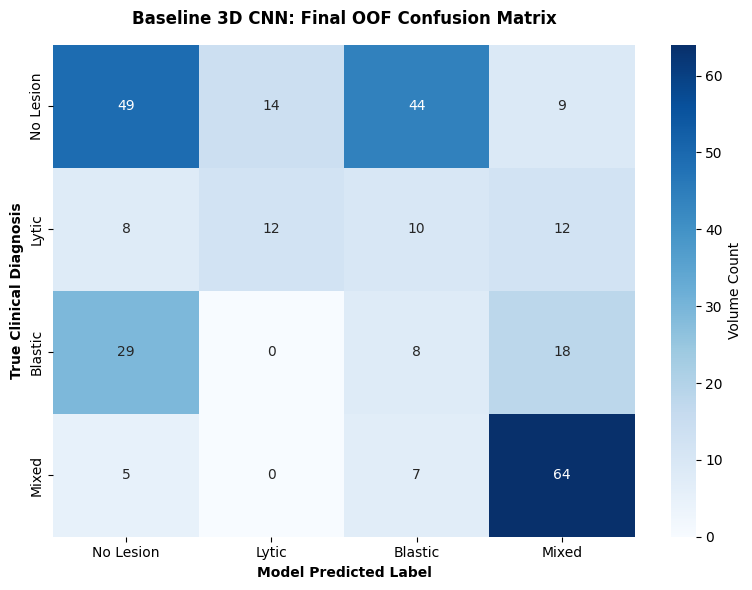

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 3. FINAL PUBLICATION METRICS & VISUALIZATION
# ==========================================
print(f"\n{'='*40}")
print("   CROSS-VALIDATION COMPLETE")
print(f"{'='*40}")
for i, acc in enumerate(fold_metrics):
    print(f"Fold {i+1}: {acc:.4f}")
print(f"\nAverage Model Accuracy: {np.mean(fold_metrics):.4f} ± {np.std(fold_metrics):.4f}")

# Process the aggregated Out-Of-Fold predictions
oof_true_labels = np.array(oof_true_labels)
oof_pred_classes = np.argmax(oof_predictions, axis=1)
class_names = ['No Lesion', 'Lytic', 'Blastic', 'Mixed']

print("\n" + "="*60)
print("     FINAL OUT-OF-FOLD REPORT (ALL 52 PATIENTS)")
print("="*60)
print(classification_report(oof_true_labels, oof_pred_classes, target_names=class_names))

# Generate the Master Confusion Matrix
cm = confusion_matrix(oof_true_labels, oof_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Volume Count'})

plt.title('Baseline 3D CNN: Final OOF Confusion Matrix', pad=15, fontsize=12, fontweight='bold')
plt.ylabel('True Clinical Diagnosis', fontsize=10, fontweight='bold')
plt.xlabel('Model Predicted Label', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()